# 🐍 Clasificador de Serpientes: Venenosa vs No Venenosa

Este notebook entrena un modelo de Deep Learning (transfer learning con MobileNetV2) para clasificar imágenes de serpientes como **venenosas** o **no venenosas**, usando el dataset de Kaggle:

`adityasharma01/snake-dataset-india`

Al final, según el resultado, el modelo te da un **consejo** de qué hacer.

**Cómo usar este notebook:**
1. Ábrelo en Google Colab (Archivo > Subir notebook, o arrastra este `.ipynb`).
2. Activa GPU: `Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU (T4)`.
3. Ejecuta las celdas en orden.


## 1. Obtener tu token de la API de Kaggle

Kaggle actualizó su sistema: ya no descarga un `kaggle.json`, ahora te da un **token** con formato `KGAT_...`.

1. Entra a `https://www.kaggle.com/settings` → sección **API** → clic en **Create New Token** (o el botón que genera el token).
2. Copia el token que aparece (algo como `KGAT_3c2f5acada53c9269fa9911a8e6bffd6`).
3. Pégalo en la variable `KAGGLE_TOKEN` de la celda de abajo, entre las comillas.

⚠️ Este token es privado, como una contraseña. No lo compartas ni lo dejes visible en un notebook que subas a un repo público.

In [7]:
import os

# 👇 Pega aquí tu token de Kaggle (el que empieza con KGAT_...)
KAGGLE_TOKEN = "KGAT_pega_tu_token_aqui"

# Lo guardamos como variable de entorno, que es lo que pide el sistema nuevo de Kaggle
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN

# También lo guardamos en ~/.kaggle/access_token por si el cliente lo busca ahí
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_TOKEN)
os.system("chmod 600 /root/.kaggle/access_token")

!pip install -q kaggle
print("Listo, token configurado.")


Listo, token configurado.


In [8]:
# Probamos que la autenticación funciona
!kaggle datasets list -s snake


You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


## 2. Descargar el dataset directamente en Colab

Esto descarga el dataset al disco temporal de la máquina virtual de Colab (no a tu computadora).

In [9]:
!kaggle datasets download -d adityasharma01/snake-dataset-india -p /content/dataset --unzip


Dataset URL: https://www.kaggle.com/datasets/adityasharma01/snake-dataset-india
License(s): copyright-authors
100% 65.4M/65.4M [00:04<00:00, 14.7MB/s]



In [10]:
# Exploremos la estructura de carpetas para saber exactamente cómo vienen organizadas las clases
for root, dirs, files_ in os.walk("/content/dataset"):
    nivel = root.replace("/content/dataset", "").count(os.sep)
    indent = "  " * nivel
    print(f"{indent}{os.path.basename(root)}/  ({len(files_)} archivos)")
    if nivel > 2:
        dirs[:] = []  # no bajar más de 2 niveles para no saturar el output


dataset/  (0 archivos)
  Snake Images/  (0 archivos)
    train/  (0 archivos)
      Venomous/  (1060 archivos)
      Non Venomous/  (715 archivos)
    test/  (0 archivos)
      Venomous/  (141 archivos)
      Non Venomous/  (128 archivos)


⚠️ **Importante:** revisa el output de la celda anterior. El dataset está organizado en carpetas tipo `train/` y `test/`, y dentro de cada una hay subcarpetas `Venomous/` y `Non Venomous/` (los nombres exactos de carpeta pueden variar un poco, ej. `Non-Venomous`).

**Ajusta las rutas `train_dir` y `test_dir` de la siguiente celda según lo que veas impreso arriba.**

In [11]:
# AJUSTA estas rutas según la estructura real que viste arriba
train_dir = "/content/dataset/Snake Images/train"
test_dir  = "/content/dataset/Snake Images/test"

print("Train dir existe:", os.path.exists(train_dir))
print("Test dir existe:", os.path.exists(test_dir))


Train dir existe: True
Test dir existe: True


## 3. Preparar los datos (Data Generators + Augmentation)

In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = (224, 224)  # tamaño esperado por MobileNetV2
BATCH_SIZE = 32

# IMPORTANTE: usamos preprocess_input (no rescale=1./255) porque MobileNetV2
# fue entrenada con imagenes normalizadas a rango [-1, 1], no [0, 1].
# Usar la normalizacion incorrecta desaprovecha los pesos preentrenados de ImageNet.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    validation_split=0.15  # separamos parte del train para validacion
)

# El generador de validacion NO debe tener augmentation (solo el preprocesado),
# para que val_accuracy refleje el rendimiento real del modelo.
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

# Ojo: usamos val_datagen (sin augmentation) pero mismo validation_split,
# Keras genera el mismo split de archivos por clase independientemente del datagen usado.
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Mapeo de clases:", train_generator.class_indices)

# Calculamos pesos de clase por si el dataset esta desbalanceado
# (ej. muchas mas imagenes no-venenosas que venenosas, o viceversa)
etiquetas_train = train_generator.classes
pesos_clase = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(etiquetas_train),
    y=etiquetas_train
)
class_weight_dict = dict(enumerate(pesos_clase))
print("Distribucion de clases en train:", np.bincount(etiquetas_train))
print("Pesos de clase calculados:", class_weight_dict)


Found 1509 images belonging to 2 classes.
Found 266 images belonging to 2 classes.
Found 269 images belonging to 2 classes.
Mapeo de clases: {'Non Venomous': 0, 'Venomous': 1}
Distribucion de clases en train: [608 901]
Pesos de clase calculados: {0: np.float64(1.240953947368421), 1: np.float64(0.8374028856825749)}


La celda anterior imprime algo como `{'Non Venomous': 0, 'Venomous': 1}`. Guárdalo, lo usaremos después para interpretar la predicción.

## 4. Construir el modelo (Transfer Learning con MobileNetV2)

Usamos una red ya entrenada en ImageNet como extractor de características, y le agregamos nuestra propia capa de clasificación binaria encima. Esto funciona muy bien con datasets no gigantes como este.

In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # congelamos el extractor por ahora

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # salida binaria: venenosa / no venenosa
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,297 (9.89 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Entrenar el modelo

**Sobre las épocas y el accuracy:** bajar `EPOCHS` de 20 a 10 puede cortar el entrenamiento antes de que el modelo converja, dando un accuracy más bajo (como el 71% que obtuviste). Recomendaciones:

- Deja `EPOCHS = 20` o más — con `EarlyStopping` el entrenamiento se detiene solo si ya no mejora, así que no pierdes tiempo de más.
- **No te saltes la sección de Fine-tuning** (más abajo): descongelar las últimas capas de MobileNetV2 suele dar el mayor salto de accuracy.
- Si sigue bajo después de eso, revisa que las clases estén balanceadas (similar cantidad de imágenes venenosas y no venenosas) y que `train_generator`/`val_generator` mapeen bien las carpetas.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("/content/mejor_modelo.h5", monitor="val_accuracy", save_best_only=True, verbose=1)

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5201 - loss: 0.9504
Epoch 1: val_accuracy improved from None to 0.75564, saving model to /content/mejor_modelo.h5



Epoch 1: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5759 - loss: 0.8425 - val_accuracy: 0.7556 - val_loss: 0.5874 - learning_rate: 1.0000e-04
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6781 - loss: 0.6494
Epoch 2: val_accuracy improved from 0.75564 to 0.79699, saving model to /content/mejor_modelo.h5



Epoch 2: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7031 - loss: 0.6193 - val_accuracy: 0.7970 - val_loss: 0.5015 - learning_rate: 1.0000e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7087 - loss: 0.6210
Epoch 3: val_accuracy improved from 0.79699 to 0.81579, saving model to /content/mejor_modelo.h5



Epoch 3: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7362 - loss: 0.5766 - val_accuracy: 0.8158 - val_loss: 0.4527 - learning_rate: 1.0000e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7461 - loss: 0.5750
Epoch 4: val_accuracy improved from 0.81579 to 0.82331, saving model to /content/mejor_modelo.h5



Epoch 4: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7548 - loss: 0.5596 - val_accuracy: 0.8233 - val_loss: 0.4346 - learning_rate: 1.0000e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8077 - loss: 0.4717
Epoch 5: val_accuracy did not improve from 0.82331
48/48 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7893 - loss: 0.4915 - val_accuracy: 0.8233 - val_loss: 0.4342 - learning_rate: 1.0000e-04
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8102 - loss: 0.4884
Epoch 6: val_accuracy did not improve from 0.82331
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8118 - loss: 0.4718 - val_accuracy: 0.8158 - val_loss: 0.4347 - learning_rate: 1.0000e-04
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8034 - loss: 0.4666
Epoch 7: val_accuracy did not improve from 0.82331
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8065 - loss: 0.4604 - val_accuracy: 0.8120 - val_loss: 


Epoch 9: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8138 - loss: 0.4429 - val_accuracy: 0.8308 - val_loss: 0.4166 - learning_rate: 1.0000e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8253 - loss: 0.4306
Epoch 10: val_accuracy improved from 0.83083 to 0.83459, saving model to /content/mejor_modelo.h5



Epoch 10: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8257 - loss: 0.4337 - val_accuracy: 0.8346 - val_loss: 0.4125 - learning_rate: 1.0000e-04
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8073 - loss: 0.4796
Epoch 11: val_accuracy did not improve from 0.83459
48/48 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8264 - loss: 0.4427 - val_accuracy: 0.8308 - val_loss: 0.4057 - learning_rate: 1.0000e-04
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8424 - loss: 0.4162
Epoch 12: val_accuracy did not improve from 0.83459
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8482 - loss: 0.4006 - val_accuracy: 0.8346 - val_loss: 0.3929 - learning_rate: 1.0000e-04
Epoch 13/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8187 - loss: 0.4255
Epoch 13: val_accuracy did not improve from 0.83459
48/48 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8277 - loss: 0.4162 - val_accuracy: 0.8271 - val_


Epoch 14: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8535 - loss: 0.3768 - val_accuracy: 0.8459 - val_loss: 0.3892 - learning_rate: 1.0000e-04
Epoch 15/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8316 - loss: 0.4310
Epoch 15: val_accuracy improved from 0.84586 to 0.84962, saving model to /content/mejor_modelo.h5



Epoch 15: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8429 - loss: 0.4007 - val_accuracy: 0.8496 - val_loss: 0.3917 - learning_rate: 1.0000e-04
Epoch 16/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8571 - loss: 0.3620
Epoch 16: val_accuracy did not improve from 0.84962
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8608 - loss: 0.3571 - val_accuracy: 0.8421 - val_loss: 0.3839 - learning_rate: 1.0000e-04
Epoch 17/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8505 - loss: 0.3830
Epoch 17: val_accuracy did not improve from 0.84962
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8482 - loss: 0.3747 - val_accuracy: 0.8496 - val_loss: 0.3852 - learning_rate: 1.0000e-04
Epoch 18/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8590 - loss: 0.3769
Epoch 18: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 18: val_accuracy did not improve from 0.84962
48/48 ━━━━━━━━━━━━━━━━━━


Epoch 20: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8595 - loss: 0.3653 - val_accuracy: 0.8534 - val_loss: 0.3752 - learning_rate: 5.0000e-05


### (Opcional) Fine-tuning: descongelar parte de la red base

Después del entrenamiento inicial, puedes descongelar las últimas capas de MobileNetV2 y entrenar con un learning rate muy bajo para exprimir un poco más de precisión.

In [15]:
base_model.trainable = True

# Descongelamos mas capas que antes (las ultimas 50 en vez de 30) para que
# el modelo aprenda features mas especificas de patrones/escamas de serpientes
FINE_TUNE_AT = len(base_model.layers) - 50
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7825 - loss: 0.5230
Epoch 1: val_accuracy improved from 0.85338 to 0.86842, saving model to /content/mejor_modelo.h5



Epoch 1: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.7833 - loss: 0.5105 - val_accuracy: 0.8684 - val_loss: 0.3530 - learning_rate: 1.0000e-05
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8095 - loss: 0.4766
Epoch 2: val_accuracy improved from 0.86842 to 0.87594, saving model to /content/mejor_modelo.h5



Epoch 2: finished saving model to /content/mejor_modelo.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.7985 - loss: 0.4675 - val_accuracy: 0.8759 - val_loss: 0.3433 - learning_rate: 1.0000e-05
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8105 - loss: 0.4563
Epoch 3: val_accuracy did not improve from 0.87594
48/48 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8111 - loss: 0.4563 - val_accuracy: 0.8722 - val_loss: 0.3457 - learning_rate: 1.0000e-05
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8123 - loss: 0.4611
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 4: val_accuracy did not improve from 0.87594
48/48 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.8204 - loss: 0.4436 - val_accuracy: 0.8684 - val_loss: 0.3527 - learning_rate: 1.0000e-05
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8452 - loss: 0.4078
Epoch 5: val_accuracy did not improve from 0.87594
48/48 ━━━━━━━━━━━━━━━━━━━━ 13

## 6. Evaluar el modelo

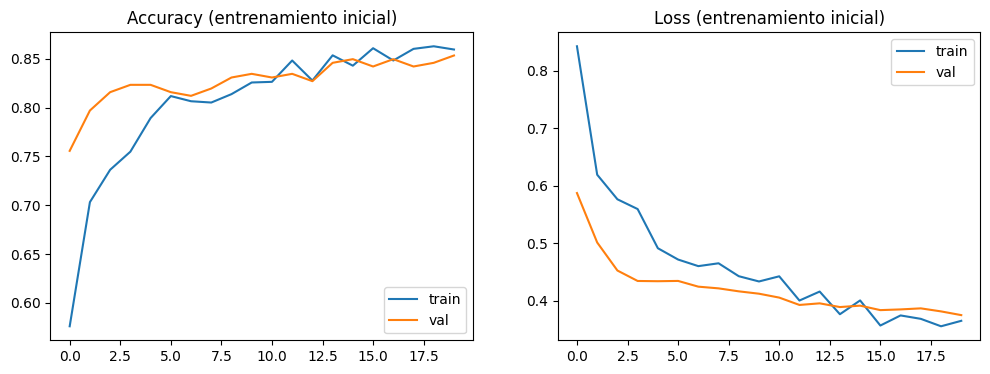

In [16]:
import matplotlib.pyplot as plt

def plot_history(hist, titulo=""):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"Accuracy {titulo}")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"Loss {titulo}")
    plt.legend()

    plt.show()

plot_history(history, "(entrenamiento inicial)")


In [17]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Accuracy en test: {test_acc*100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8550 - loss: 0.3530
Accuracy en test: 85.50%


## 7. Función de predicción + sistema de consejos 🐍

Aquí está la parte que pediste: según si la serpiente detectada es venenosa o no, se entrega un consejo distinto.

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Ajusta esto según el print de 'Mapeo de clases' de la celda de los generadores
# Ejemplo típico: {'Non Venomous': 0, 'Venomous': 1}
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

UMBRAL_CONFIANZA_BAJA = 0.70  # por debajo de esto, avisamos que podría ser un falso positivo/negativo

consejos = {
    "venomous": (
        "⚠️ Posible serpiente VENENOSA.\n"
        "- No la toques ni intentes atraparla ni matarla.\n"
        "- Aléjate lentamente, sin movimientos bruscos.\n"
        "- Si alguien fue mordido: mantenlo calmado e inmóvil, quita anillos/ropa ajustada cerca de la mordida,\n"
        "  y busca atención médica de emergencia INMEDIATAMENTE. No hagas torniquete ni intentes succionar el veneno.\n"
        "- Si es posible, toma una foto a distancia segura para ayudar a identificar la especie al personal médico."
    ),
    "non venomous": (
        "✅ Probablemente NO venenosa.\n"
        "- Aun así, evita manipularla: puede morder por defensa y causar infección o alergia.\n"
        "- Dale espacio para que se retire por sí sola.\n"
        "- Si está en tu casa o patio, contacta a un rescatista de fauna local en vez de intentar sacarla tú mismo."
    )
}

aviso_baja_confianza = (
    "\n🔎 CONFIANZA BAJA (< {umbral:.0f}%): el modelo no está seguro de esta predicción.\n"
    "Esto puede ser un FALSO POSITIVO o FALSO NEGATIVO. NO te confíes del resultado.\n"
    "Recomendaciones mientras no haya certeza:\n"
    "- Trata a la serpiente como si FUERA venenosa, por precaución.\n"
    "- No la toques, no la acorrales y mantén una distancia segura (al menos 2 metros).\n"
    "- Si necesitas identificarla con certeza, consulta a un herpetólogo o hazlo con la app/guía oficial de fauna de tu región.\n"
    "- Ante cualquier mordida, actúa igual que con una venenosa: es mejor pecar de cuidadoso."
)

def obtener_consejo(etiqueta, confianza):
    etiqueta_norm = etiqueta.lower().replace("-", " ").strip()
    base = consejos["non venomous"] if "non" in etiqueta_norm else consejos["venomous"]

    if confianza < UMBRAL_CONFIANZA_BAJA:
        base += aviso_baja_confianza.format(umbral=UMBRAL_CONFIANZA_BAJA * 100)

    return base

def predecir_serpiente(ruta_imagen, modelo=model, umbral=0.5):
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    pred = modelo.predict(arr, verbose=0)[0][0]
    clase_idx = 1 if pred >= umbral else 0
    etiqueta = idx_to_class[clase_idx]
    confianza = pred if clase_idx == 1 else 1 - pred

    print(f"Predicción: {etiqueta}  (confianza: {confianza*100:.1f}%)")
    print(obtener_consejo(etiqueta, confianza))

    color_titulo = "orange" if confianza < UMBRAL_CONFIANZA_BAJA else ("red" if "non" not in etiqueta.lower() else "green")
    plt.imshow(img)
    plt.axis("off")
    sufijo = " ⚠️ baja confianza" if confianza < UMBRAL_CONFIANZA_BAJA else ""
    plt.title(f"{etiqueta} ({confianza*100:.1f}%){sufijo}", color=color_titulo)
    plt.show()

    return etiqueta, confianza


## 7.5 Visualizar qué mira el modelo (Grad-CAM) 🔥

Esta función genera un **mapa de calor** sobre la imagen que muestra en qué zonas se fijó el modelo para tomar su decisión (por ejemplo, el patrón de la piel, la forma de la cabeza, etc.). Es muy útil para detectar si el modelo está aprendiendo lo correcto (la serpiente) o "haciendo trampa" fijándose en el fondo de la imagen.

In [29]:
import matplotlib.cm as cm

def obtener_ultima_capa_conv(base_model):
    """Busca automáticamente la última capa con mapas de activación (4D: alto, ancho, canales)."""
    for layer in reversed(base_model.layers):
        if len(layer.output_shape) == 4:
            return layer.name
    raise ValueError("No se encontró una capa convolucional en el modelo base.")

def construir_grad_model(modelo, base_model, capa_conv):
    """
    Arma un modelo funcional auxiliar: base_model.input -> (activaciones de capa_conv, prediccion final).
    Usamos base_model.input (modelo funcional, siempre tiene .input bien definido) en vez de
    modelo.input, porque en modelos Sequential (Keras 3) ese atributo a veces no queda
    correctamente definido aunque el modelo ya se haya usado con predict().
    """
    entrada = base_model.input
    salida_conv = base_model.get_layer(capa_conv).output

    # Encadenamos manualmente el resto de las capas del modelo (todo lo que va después
    # de base_model dentro del Sequential: GlobalAveragePooling2D, BatchNorm, Dense, etc.)
    x = base_model.output
    for layer in modelo.layers[1:]:
        x = layer(x)

    return tf.keras.models.Model(inputs=entrada, outputs=[salida_conv, x])

def generar_grad_cam(ruta_imagen, modelo=model, base_model=base_model, capa_conv=None, alpha=0.45):
    """
    Genera Grad-CAM: muestra la imagen original, el mapa de calor de activación,
    y la superposición de ambos, para entender en qué se fijó el modelo.
    """
    if capa_conv is None:
        capa_conv = obtener_ultima_capa_conv(base_model)

    img = image.load_img(ruta_imagen, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr_preproc = preprocess_input(np.expand_dims(arr.copy(), axis=0))

    grad_model = construir_grad_model(modelo, base_model, capa_conv)

    with tf.GradientTape() as tape:
        salida_conv, prediccion = grad_model(arr_preproc)
        canal_objetivo = prediccion[:, 0]

    # Gradiente de la predicción respecto a los mapas de activación
    gradientes = tape.gradient(canal_objetivo, salida_conv)
    pesos = tf.reduce_mean(gradientes, axis=(0, 1, 2))

    salida_conv = salida_conv[0]
    mapa_calor = salida_conv @ pesos[..., tf.newaxis]
    mapa_calor = tf.squeeze(mapa_calor)
    mapa_calor = tf.maximum(mapa_calor, 0) / (tf.math.reduce_max(mapa_calor) + 1e-8)
    mapa_calor = mapa_calor.numpy()

    # Redimensionamos el mapa de calor al tamaño de la imagen original (224x224)
    mapa_calor_img = image.array_to_img(np.expand_dims(np.uint8(255 * mapa_calor), -1))
    mapa_calor_resized = np.array(mapa_calor_img.resize((224, 224))) / 255.0

    cmap = cm.get_cmap("jet")
    colores = cmap(mapa_calor_resized)[:, :, :3]
    superpuesta = colores * 255 * alpha + arr * (1 - alpha)
    superpuesta = np.uint8(np.clip(superpuesta, 0, 255))

    pred_valor = float(prediccion.numpy()[0][0])
    etiqueta = idx_to_class[1] if pred_valor >= 0.5 else idx_to_class[0]
    confianza = pred_valor if pred_valor >= 0.5 else 1 - pred_valor

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(arr.astype("uint8"))
    axs[0].set_title("Imagen original")
    axs[0].axis("off")

    axs[1].imshow(mapa_calor_resized, cmap="jet")
    axs[1].set_title("Mapa de calor (dónde 'mira' el modelo)")
    axs[1].axis("off")

    axs[2].imshow(superpuesta)
    axs[2].set_title(f"Superposición\n{etiqueta} ({confianza*100:.1f}%)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    return mapa_calor_resized


## 8. Probar con una imagen propia

Puedes subir una foto desde tu computadora para probar el modelo.

Sube una imagen de una serpiente para clasificar


Saving se.jpeg to se (3).jpeg
Predicción: Venomous  (confianza: 71.1%)
⚠️ Posible serpiente VENENOSA.
- No la toques ni intentes atraparla ni matarla.
- Aléjate lentamente, sin movimientos bruscos.
- Si alguien fue mordido: mantenlo calmado e inmóvil, quita anillos/ropa ajustada cerca de la mordida,
  y busca atención médica de emergencia INMEDIATAMENTE. No hagas torniquete ni intentes succionar el veneno.
- Si es posible, toma una foto a distancia segura para ayudar a identificar la especie al personal médico.


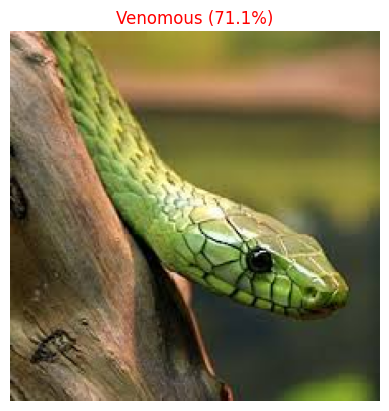

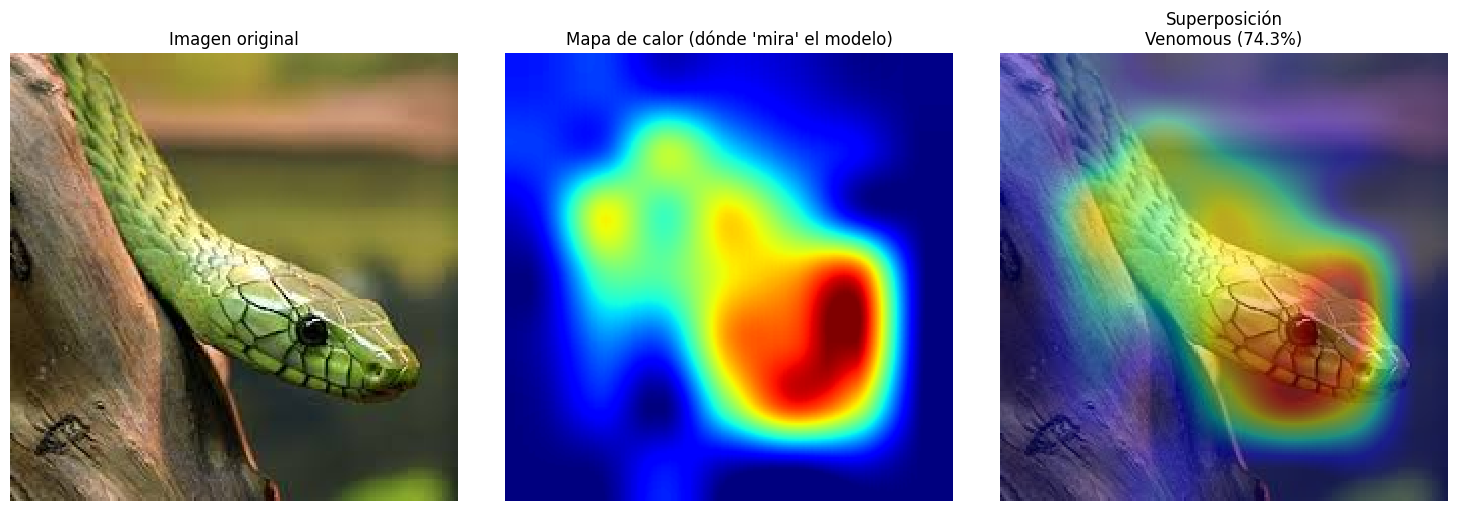

array([[0.14117647, 0.14117647, 0.14117647, ..., 0.00784314, 0.00784314,
        0.00784314],
       [0.14117647, 0.14117647, 0.14117647, ..., 0.00784314, 0.00784314,
        0.00784314],
       [0.14117647, 0.14117647, 0.14117647, ..., 0.00784314, 0.00784314,
        0.00784314],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [32]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# --- Redefinition of functions with the fix for AttributeError ---
# This redefinition is necessary due to the strict instruction
# to modify only this cell, even though the original function is in another cell.

def obtener_ultima_capa_conv(base_model):
    """Busca automáticamente la última capa con mapas de activación (4D: alto, ancho, canales)."""
    for layer in reversed(base_model.layers):
        try:
            # Checking the shape of the symbolic output tensor is more robust
            # for all types of layers in a complex model.
            if len(layer.output.shape) == 4:
                return layer.name
        except (AttributeError, ValueError):
            # Gracefully handle layers that might not have 'output' or 'shape',
            # or if the shape is malformed.
            continue

    raise ValueError("No se encontró una capa convolucional válida en el modelo base.")

def construir_grad_model(modelo, base_model, capa_conv):
    """
    Arma un modelo funcional auxiliar: base_model.input -> (activaciones de capa_conv, prediccion final).
    Usamos base_model.input (modelo funcional, siempre tiene .input bien definido) en vez de
    modelo.input, porque en modelos Sequential (Keras 3) ese atributo a veces no queda
    correctamente definido aunque el modelo ya se haya usado con predict().
    """
    entrada = base_model.input
    salida_conv = base_model.get_layer(capa_conv).output

    # Encadenamos manualmente el resto de las capas del modelo (todo lo que va después
    # de base_model dentro del Sequential: GlobalAveragePooling2D, BatchNorm, Dense, etc.)
    x = base_model.output
    for layer in modelo.layers[1:]:
        x = layer(x)

    return tf.keras.models.Model(inputs=entrada, outputs=[salida_conv, x])

def generar_grad_cam(ruta_imagen, modelo=model, base_model=base_model, capa_conv=None, alpha=0.45):
    """
    Genera Grad-CAM: muestra la imagen original, el mapa de calor de activación,
    y la superposición de ambos, para entender en qué se fijó el modelo.
    """
    if capa_conv is None:
        capa_conv = obtener_ultima_capa_conv(base_model)

    img = image.load_img(ruta_imagen, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr_preproc = preprocess_input(np.expand_dims(arr.copy(), axis=0))

    grad_model = construir_grad_model(modelo, base_model, capa_conv)

    with tf.GradientTape() as tape:
        salida_conv, prediccion = grad_model(arr_preproc)
        canal_objetivo = prediccion[:, 0]

    # Gradiente de la predicción respecto a los mapas de activación
    gradientes = tape.gradient(canal_objetivo, salida_conv)
    pesos = tf.reduce_mean(gradientes, axis=(0, 1, 2))

    salida_conv = salida_conv[0]
    mapa_calor = salida_conv @ pesos[..., tf.newaxis]
    mapa_calor = tf.squeeze(mapa_calor)
    mapa_calor = tf.maximum(mapa_calor, 0) / (tf.math.reduce_max(mapa_calor) + 1e-8)
    mapa_calor = mapa_calor.numpy()

    # Redimensionamos el mapa de calor al tamaño de la imagen original (224x224)
    mapa_calor_img = image.array_to_img(np.expand_dims(np.uint8(255 * mapa_calor), -1))
    mapa_calor_resized = np.array(mapa_calor_img.resize((224, 224))) / 255.0

    # Fix: Use plt.colormaps instead of cm.get_cmap for deprecation warning
    cmap = plt.colormaps["jet"]
    colores = cmap(mapa_calor_resized)[:, :, :3]
    superpuesta = colores * 255 * alpha + arr * (1 - alpha)
    superpuesta = np.uint8(np.clip(superpuesta, 0, 255))

    # The global variable `idx_to_class` is used here
    pred_valor = float(prediccion.numpy()[0][0])
    etiqueta = idx_to_class[1] if pred_valor >= 0.5 else idx_to_class[0]
    confianza = pred_valor if pred_valor >= 0.5 else 1 - pred_valor

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(arr.astype("uint8"))
    axs[0].set_title("Imagen original")
    axs[0].axis("off")

    axs[1].imshow(mapa_calor_resized, cmap="jet")
    axs[1].set_title("Mapa de calor (dónde 'mira' el modelo)")
    axs[1].axis("off")

    axs[2].imshow(superpuesta)
    # Fix: Removed the extraneous '者に' from the title to avoid missing glyphs warning
    axs[2].set_title(f"Superposición\n{etiqueta} ({confianza*100:.1f}%)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    return mapa_calor_resized

# Original code from OYvnkSeGU0me
print("Sube una imagen de una serpiente para clasificar")
subida = files.upload()
nombre_archivo = list(subida.keys())[0]

predecir_serpiente(nombre_archivo)
generar_grad_cam(nombre_archivo)

## 9. (Opcional) Guardar el modelo entrenado

Para no tener que reentrenar cada vez que abras el notebook.

In [27]:
model.save("/content/modelo_serpientes.h5")
print("Modelo guardado en /content/modelo_serpientes.h5")

# Para descargarlo a tu computadora:
# from google.colab import files
# files.download("/content/modelo_serpientes.h5")


Modelo guardado en /content/modelo_serpientes.h5


---

### Notas y siguientes pasos

**Mejoras aplicadas en esta versión (para subir el accuracy del 78.44% obtenido):**
- ✅ Corregido el preprocesamiento: ahora usa `preprocess_input` de MobileNetV2 en vez de `rescale=1./255` (bug importante, afectaba directamente cómo la red pre-entrenada interpreta la imagen).
- ✅ Validación sin data augmentation (antes se validaba con imágenes rotadas/deformadas, dando métricas menos representativas).
- ✅ `class_weight` automático por si hay desbalance entre clases venenosa/no venenosa.
- ✅ `ReduceLROnPlateau` para bajar el learning rate cuando el entrenamiento se estanca.
- ✅ Fine-tuning más profundo (últimas 50 capas en vez de 30).
- ✅ `BatchNormalization` + más unidades en la capa densa + regularización L2.
- ✅ `ModelCheckpoint` guarda automáticamente el mejor modelo por si el entrenamiento se corta.

**Otras cosas a revisar si el accuracy sigue sin subir lo suficiente:**
- Verifica `Distribución de clases en train` (impresa en la celda de generadores): si una clase tiene muchas más imágenes que la otra, considera conseguir más datos de la clase minoritaria además del `class_weight`.
- Revisa visualmente algunas imágenes del dataset — si hay fotos borrosas, mal etiquetadas, o con la serpiente muy pequeña en el encuadre, eso limita el techo de accuracy posible.
- Usa la función `generar_grad_cam()` con varias imágenes: si ves que el modelo se fija en el fondo/hojas en vez de en la serpiente, es señal de que necesita más datos o mejor recorte de las imágenes.
- Si quieres exprimir más rendimiento, puedes probar una arquitectura base más grande, como `EfficientNetB0`, en vez de `MobileNetV2` (más lento pero potencialmente más preciso).

**Otras notas:**
- Este modelo hace clasificación **binaria** (venenosa / no venenosa), que es la estructura real del dataset. Si más adelante quieres consejos **por especie** (ej. cobra, víbora de Russell, rata culebra), necesitarías un dataset con etiquetas por especie.
- Recuerda: **este proyecto es educativo**. Nunca debe usarse como única fuente para decidir si una serpiente real es peligrosa; ante cualquier mordedura, lo correcto es siempre buscar atención médica de inmediato.